# Однослойный перцептрон
Демонстрация с цветочком

In [2]:
import numpy as np

# Функция активации нейрона в выходном слое и ее производная
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def dsigmoid(y):
    return y * (1 - y)

# Функция активации нейронов во внутреннем слое и ее производная
def tanh(x):
    return np.tanh(x)
def dtanh(y):
    return 1 - y * y

In [3]:
from matplotlib import pyplot as plt

class Perceptron:
    def __init__(self, X, Y, hidden_size):
        
        # Пусть n - количество признаков, m - количество объектов, k - размерность результирующего вектора
        # Тогда X = X(n * m), Y = Y(k, m)
        assert X.shape[1] == Y.shape[1]
        self.X = X
        self.Y = Y
        self.m = X.shape[1]
        
        # Инициализируем матрицы весов рандомными числами (W1 - для скрытого слоя, W2 - для выходного, в нем всего 1 нейрон)
        self.W1 = np.random.randn(hidden_size, X.shape[0])
        self.W2 = np.random.randn(Y.shape[0], hidden_size)
        
        # Заполняем свободные векторы нулями
        self.b1 = np.zeros((hidden_size, 1))
        self.b2 = np.zeros((Y.shape[0], 1))
        
        # Здесь будем накапливать значения функции потерь на каждой итерации
        self.ce_loss = []
        self.mse_loss = []
        
    def learn(self, iter_num, learning_rate):
        
        # Итерируемся необходимое количество раз
        for i in range(iter_num):
            
            # Расчет взыешенных сумм каждого из нейронов, применение функций активации
            # Для того, чтобы заменить функции активации, необходимо заменить функцию при вычислении А1/А2
            Z1 = np.dot(self.W1, self.X) + self.b1                                     # (hidden_size, X.shape[1])
            A1 = tanh(Z1)
            Z2 = np.dot(self.W2, A1) + self.b2                                         # (Y.shape[0], X.shape[1] = Y.shape[1])
            A2 = sigmoid(Z2)

            # Среднеквадратичная (MSE) функция потерь
            mse_loss = np.sum((A2 - self.Y) ** 2) / self.m
            
            # Cross entropy функция потерь
            eps = 1e-8
            logprobs = self.Y * np.log(A2 + eps) + (1 - self.Y) * np.log(1 - A2 + eps)
            ce_loss = (-1 / self.m) * np.sum(logprobs)
            
            # Запоминание значения функции потерь и печать на каждой 1000-й итерации
            self.mse_loss.append(mse_loss)
            self.ce_loss.append(ce_loss)
            if i % 1000 == 0: print(f"MSE loss: {mse_loss}, CE loss: {ce_loss}")

            # Алгоритм обратного распространения ошибки
            # Производные высчитываются по правилу производной для сложной функции
            # Оптимизируется среднеквадратичная функция потерь
            # Для оптимизации cross entropy необходимо заменить производную функции потерь по A2 - self.Y
            # Для этого необходимо найти dError/dW
            # При замене функций активации необходимо также заменить соответствующую ей производную
            dA2 = (A2 - self.Y) * dsigmoid(A2)        # dLoss/dA * dSig/dZ2            # (Y.shape[0], Y.shape[1] = X.shape[1])
            dW2 = np.dot(dA2, A1.T)                   # dZ2/dW2                        # (Y.shape[0], hidden_size)
            db2 = np.sum(dA2, axis=1, keepdims=True)                                   # (Y.shape[0], 1)
            dA1 = np.dot(self.W2.T, dA2) * dtanh(A1)  # dA2 * dZ2/dA1 * dTanh/dZ       # (hidden_size, Y.shape[1] = X.shape[1])
            dW1 = np.dot(dA1, self.X.T)               # dZ1/dW                         # (hidden_size, X.shape[0])
            db1 = np.sum(dA1, axis=1, keepdims=True)                                   # (hidden_size, 1)
            
            # Обновление весов методом градиентного спуска
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1
            
    def predict(self, X):
        # Используем найденные матрицы весов
        A1 = tanh(np.dot(self.W1, X) + self.b1)
        A2 = sigmoid(np.dot(self.W2, A1) + self.b2)
        return (A2[0] > 0.5).astype(int)
    
    def plot(self):
        plt.figure(figsize=(10,3))
        plt.subplot(1, 2, 1)
        plt.ylabel('MSE loss')
        plt.xlabel('Iterations')
        plt.plot(self.mse_loss)
        plt.subplot(1, 2, 2)
        plt.ylabel('CE loss')
        plt.xlabel('Iterations')
        plt.plot(self.ce_loss)

## Разделение цветочка

In [5]:
# Создать датасет в виде цветочка, m - кол-во объектов (целое больше 1), a - максимальная длина листа (float больше 0)
def create_flower(m, a):
    D = 2
    N = int(m/2)
    X = np.zeros((m,D))
    Y = np.zeros((m,1), dtype='uint8')
    for j in range(2):
        ix = range(N*j,N*(j+1))
        t = np.linspace(j*3.12,(j+1)*3.12,N) + np.random.randn(N)*0.2
        r = a*np.sin(4*t) + np.random.randn(N)*0.2
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        Y[ix] = j
    return X.T, Y.T

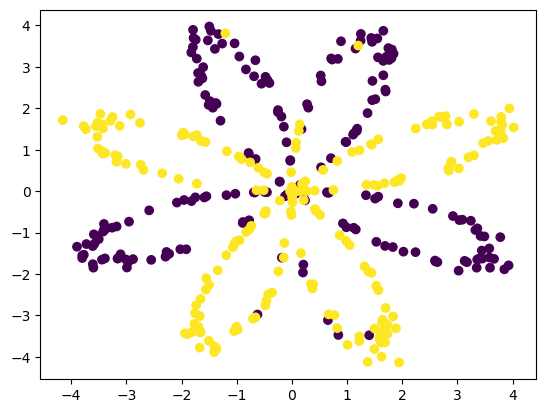

In [6]:
# Создаем и рисуем датасет в форме цветочка с 1000 объектов, цветами обозначены метки классов
X, Y = create_flower(400, 4)
plt.scatter(X[0, :], X[1, :], c=Y);

In [7]:
# Строим разделяющую  прямую, показывающую результат обучения нейросети
def plot_division(perceptron):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=Y, cmap=plt.cm.Spectral);

### Один нейрон

In [9]:
perceptron = Perceptron(X, Y, 1)
perceptron.learn(10000, 0.1)

MSE loss: 0.45205579419540803, CE loss: 1.2297592066777026
MSE loss: 0.2076425877864046, CE loss: 0.6059913544006027
MSE loss: 0.20618956430107643, CE loss: 0.6027745256372452
MSE loss: 0.20589649463803567, CE loss: 0.6021273448058849
MSE loss: 0.2057489041312478, CE loss: 0.6018017496255101
MSE loss: 0.2056546787494738, CE loss: 0.6015938142477915
MSE loss: 0.20558728910204083, CE loss: 0.6014448940100544
MSE loss: 0.20553579362810637, CE loss: 0.6013308580366493
MSE loss: 0.20549471057271743, CE loss: 0.601239647668776
MSE loss: 0.20546092957132842, CE loss: 0.6011644375680232


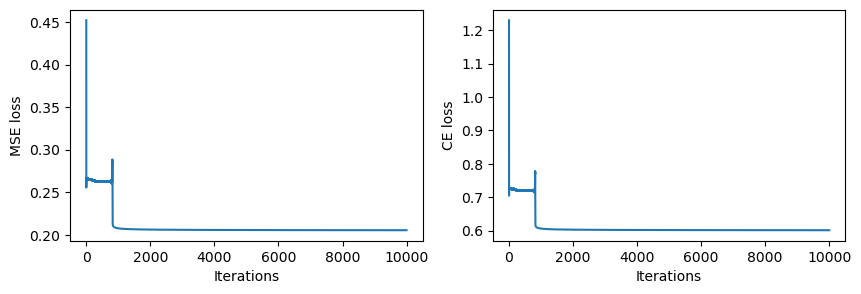

In [10]:
perceptron.plot()

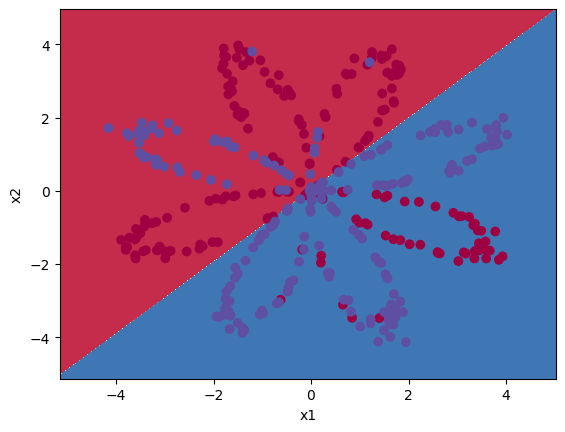

In [11]:
# Строим разделяющую  прямую, показывающую результат обучения нейросети
plot_division(perceptron)

### Четыре нейрона

In [13]:
perceptron = Perceptron(X, Y, 4)
perceptron.learn(10000, 0.1)

MSE loss: 0.25384102263497804, CE loss: 0.700848037432778
MSE loss: 0.055789386351149516, CE loss: 0.19675403131484742
MSE loss: 0.050611697298486163, CE loss: 0.17898497356348939
MSE loss: 0.049628152493021015, CE loss: 0.175078908908451
MSE loss: 0.05008048049337931, CE loss: 0.1760097572309411
MSE loss: 0.05131898268214708, CE loss: 0.17963525923491855
MSE loss: 0.05030163642059879, CE loss: 0.17693154828767546
MSE loss: 0.049464436656089336, CE loss: 0.17504854085646165
MSE loss: 0.04880706312679202, CE loss: 0.17400265199964934
MSE loss: 0.048301936092986913, CE loss: 0.17378202680796995


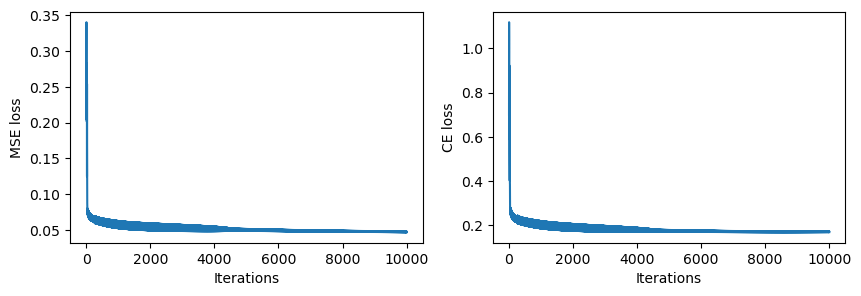

In [14]:
perceptron.plot()

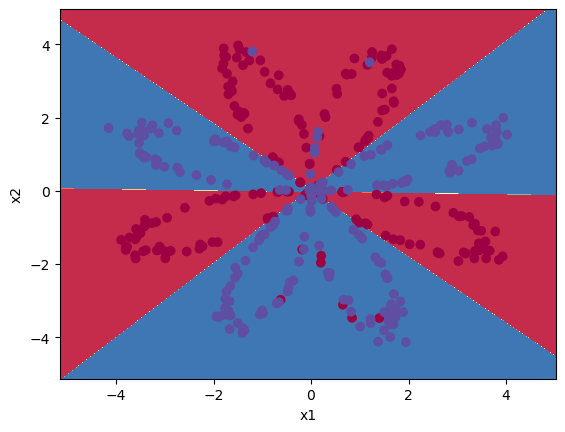

In [15]:
plot_division(perceptron)

### много нейронов - стало ли лучше?

In [17]:
perceptron = Perceptron(X, Y, 40)
perceptron.learn(10000, 0.1)

MSE loss: 0.5193718669827745, CE loss: 3.743581813796658
MSE loss: 0.05922953927826014, CE loss: 0.5288624348811736
MSE loss: 0.05161209119907809, CE loss: 0.5760420001718786
MSE loss: 0.047356921516913814, CE loss: 0.6613039654206726
MSE loss: 0.04524692674279148, CE loss: 0.6632799909462923
MSE loss: 0.046127260662179426, CE loss: 0.6651440364020752
MSE loss: 0.04633825638906479, CE loss: 0.6654796703638277
MSE loss: 0.04569927295869577, CE loss: 0.6604494347291326
MSE loss: 0.04476206881039786, CE loss: 0.6544873634257096
MSE loss: 0.04056440580570811, CE loss: 0.6275813347628849


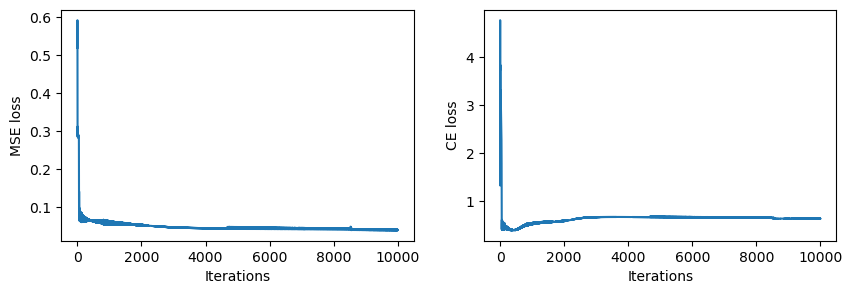

In [18]:
perceptron.plot()

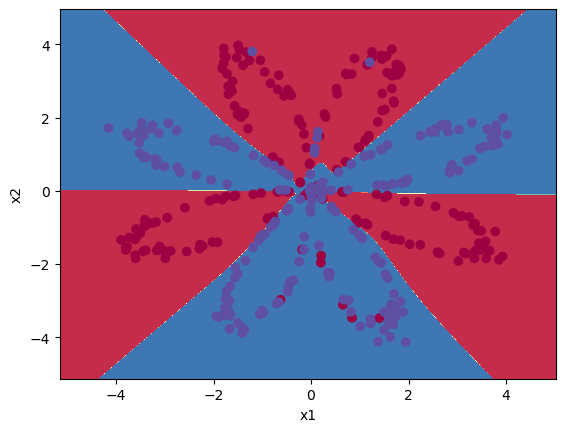

In [19]:
plot_division(perceptron)

In [35]:
a=np.array([1,2,3])
a**2

array([1, 4, 9])

In [ ]:
# Персептрон с изменениями

In [72]:
from matplotlib import pyplot as plt

class Perceptron:
    def __init__(self, X, Y, hidden_size):
        
        # Пусть n - количество признаков, m - количество объектов, k - размерность результирующего вектора
        # Тогда X = X(n * m), Y = Y(k, m)
        assert X.shape[1] == Y.shape[1]
        self.X = X
        self.Y = Y
        self.m = X.shape[1]
        
        # Инициализируем матрицы весов рандомными числами (W1 - для скрытого слоя, W2 - для выходного, в нем всего 1 нейрон)
        self.W1 = np.random.randn(hidden_size, X.shape[0])
        self.W2 = np.random.randn(Y.shape[0], hidden_size)
        
        # Заполняем свободные векторы нулями
        self.b1 = np.zeros((hidden_size, 1))
        self.b2 = np.zeros((Y.shape[0], 1))
        
        # Здесь будем накапливать значения функции потерь на каждой итерации
        self.ce_loss = []
        self.mse_loss = []
        self.mse_loss_reg = [] # добавили массив для mse с регуляризацией
        
    def learn(self, iter_num, learning_rate, lmdb):
        
        # Итерируемся необходимое количество раз
        for i in range(iter_num):
            
            # Расчет взыешенных сумм каждого из нейронов, применение функций активации
            # Для того, чтобы заменить функции активации, необходимо заменить функцию при вычислении А1/А2
            Z1 = np.dot(self.W1, self.X) + self.b1                                     # (hidden_size, X.shape[1])
            A1 = tanh(Z1)
            Z2 = np.dot(self.W2, A1) + self.b2                                         # (Y.shape[0], X.shape[1] = Y.shape[1])
            A2 = sigmoid(Z2)

            # Среднеквадратичная (MSE) функция потерь
            mse_loss = np.sum((A2 - self.Y) ** 2) / self.m
            mse_loss_reg = np.sum((A2 - self.Y) ** 2) / self.m + lmdb / (2*self.m) * np.sum(self.W1**2) + lmdb / (2*self.m) * np.sum(self.W2**2) 
            # + lmdb / (2*self.m) * np.sum(self.W1**2) + lmdb / (2*self.m) * np.sum(self.W2**2)
            # добавил штраф за сложность с параметром lmdb, регуляризацию L2, за веса W1 и W2
            # в описании задания квадрата не было, но по лекциям из ML это LASSO регуляризация (правда еще модуль добавить надо), поэтому скорее всего опечатка и нужен квадрат, 
            # тем более в подсказке говорится о квадратах
            
            # Cross entropy функция потерь
            eps = 1e-8
            logprobs = self.Y * np.log(A2 + eps) + (1 - self.Y) * np.log(1 - A2 + eps)
            ce_loss = (-1 / self.m) * np.sum(logprobs)
            
            # Запоминание значения функции потерь и печать на каждой 1000-й итерации
            self.mse_loss.append(mse_loss)
            self.mse_loss_reg.append(mse_loss_reg)
            self.ce_loss.append(ce_loss)
            if i % 1000 == 0: print(f"MSE loss: {mse_loss}, MSE_Reg loss: {mse_loss_reg}, CE loss: {ce_loss}")

            # Алгоритм обратного распространения ошибки
            # Производные высчитываются по правилу производной для сложной функции
            # Оптимизируется среднеквадратичная функция потерь
            # Для оптимизации cross entropy необходимо заменить производную функции потерь по A2 - self.Y
            # Для этого необходимо найти dError/dW
            # При замене функций активации необходимо также заменить соответствующую ей производную
            dA2 = (A2 - self.Y) * dsigmoid(A2)        # dLoss/dA * dSig/dZ2            # (Y.shape[0], Y.shape[1] = X.shape[1])
            # dW2 = np.dot(dA2, A1.T)                   # dZ2/dW2                        # (Y.shape[0], hidden_size)
            dW2 = np.dot(dA2, A1.T) + (lmdb / self.m * self.W2)  # + (lmdb / m * W2), взяли производную по W2 поэтому 2-ки сократились, регуляризация L2, штраф за сложность 
            db2 = np.sum(dA2, axis=1, keepdims=True)                                   # (Y.shape[0], 1)
            dA1 = np.dot(self.W2.T, dA2) * dtanh(A1)  # dA2 * dZ2/dA1 * dTanh/dZ       # (hidden_size, Y.shape[1] = X.shape[1])
            # dW1 = np.dot(dA1, self.X.T)               # dZ1/dW                         # (hidden_size, X.shape[0])
            dW1 = np.dot(dA1, self.X.T) + (lmdb / self.m * self.W1) # аналогично dW2 
            db1 = np.sum(dA1, axis=1, keepdims=True)                                   # (hidden_size, 1)
            
            # Обновление весов методом градиентного спуска
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1
            
    def predict(self, X):
        # Используем найденные матрицы весов
        A1 = tanh(np.dot(self.W1, X) + self.b1)
        A2 = sigmoid(np.dot(self.W2, A1) + self.b2)
        return (A2[0] > 0.5).astype(int)
    
    def plot(self):
        plt.figure(figsize=(10,4))
        plt.subplot(1, 3, 1)
        plt.ylabel('MSE loss')
        plt.xlabel('Iterations')
        plt.plot(self.mse_loss)
        plt.subplot(1, 3, 2)
        plt.ylabel('MSE_Reg loss')
        plt.xlabel('Iterations')
        plt.plot(self.mse_loss_reg)
        plt.subplot(1, 3, 3)
        plt.ylabel('CE loss')
        plt.xlabel('Iterations')
        plt.plot(self.ce_loss)

In [48]:
# 1 нейрон начнем с lmdb = 0.1 по причине: а почему бы и нет

In [74]:
perceptron = Perceptron(X, Y, 1)
perceptron.learn(10000, 0.1, 0.1)

MSE loss: 0.2629569568641896, MSE_Reg loss: 0.26308191495826067, CE loss: 0.7192286454073126
MSE loss: 0.28667440523189636, MSE_Reg loss: 0.290032695803248, CE loss: 0.7727651649298451
MSE loss: 0.28560391280113806, MSE_Reg loss: 0.2921601720973178, CE loss: 0.7704202502516942
MSE loss: 0.2850940864562895, MSE_Reg loss: 0.2946422011320037, CE loss: 0.7693315134623063
MSE loss: 0.28479231884163014, MSE_Reg loss: 0.29711923638266474, CE loss: 0.7687029795685593
MSE loss: 0.2845884911859366, MSE_Reg loss: 0.29951637017975274, CE loss: 0.7682882345038636
MSE loss: 0.2844381741892181, MSE_Reg loss: 0.30181912364533797, CE loss: 0.7679885205655222
MSE loss: 0.2843202765072819, MSE_Reg loss: 0.30402790913686684, CE loss: 0.7677572880685258
MSE loss: 0.28422364945626283, MSE_Reg loss: 0.3061465346733323, CE loss: 0.7675701518682718
MSE loss: 0.2841419028345907, MSE_Reg loss: 0.3081791336940758, CE loss: 0.7674132902749026


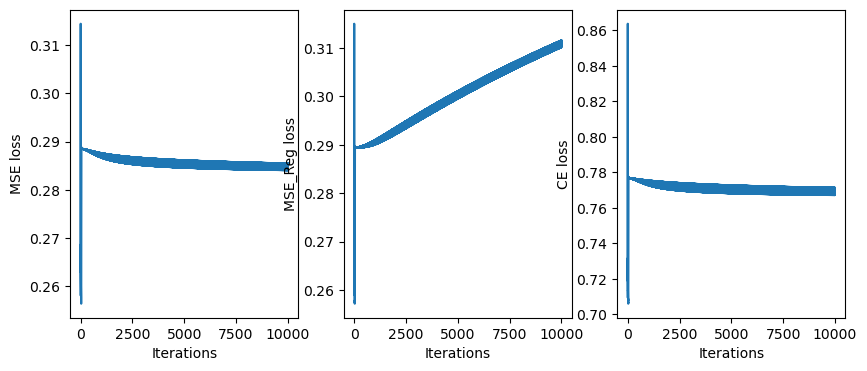

In [75]:
perceptron.plot()

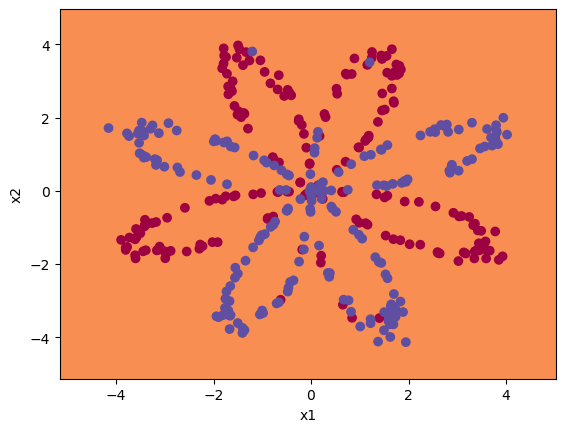

In [78]:
plot_division(perceptron)

In [ ]:
# 4 нейрона

In [80]:
perceptron = Perceptron(X, Y, 4)
perceptron.learn(10000, 0.1, 0.1)

MSE loss: 0.2985319067820898, MSE_Reg loss: 0.2995049159306341, CE loss: 0.8506700179738502
MSE loss: 0.055028638364055894, MSE_Reg loss: 0.13088036346413662, CE loss: 0.20058009978126218
MSE loss: 0.050315488830673674, MSE_Reg loss: 0.1723634217350288, CE loss: 0.19140928267731455
MSE loss: 0.04896348886203059, MSE_Reg loss: 0.20019518522512342, CE loss: 0.18861845748473896
MSE loss: 0.04828823900424923, MSE_Reg loss: 0.2231455133656637, CE loss: 0.18655464862690246
MSE loss: 0.047835076025997736, MSE_Reg loss: 0.24289744433307772, CE loss: 0.1847779135049956
MSE loss: 0.04750328297215553, MSE_Reg loss: 0.26012201643979604, CE loss: 0.18329143941477344
MSE loss: 0.04724845265335733, MSE_Reg loss: 0.27524984674172137, CE loss: 0.18206729965902185
MSE loss: 0.04704674147251149, MSE_Reg loss: 0.2886060942237281, CE loss: 0.18106110651836177
MSE loss: 0.04688366475597015, MSE_Reg loss: 0.30045315826140834, CE loss: 0.18023023596560564


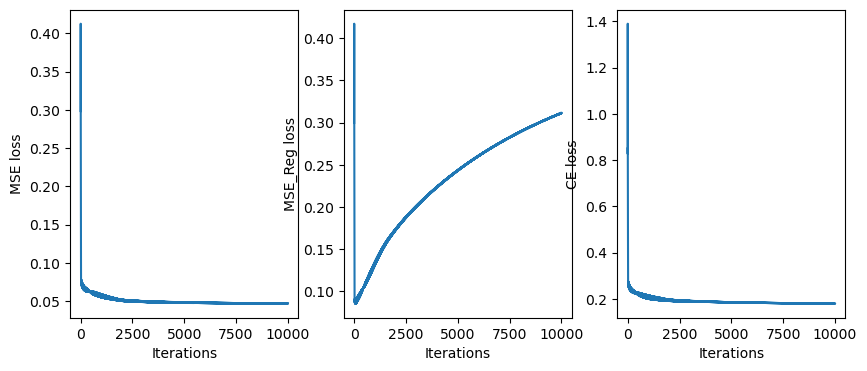

In [81]:
perceptron.plot()

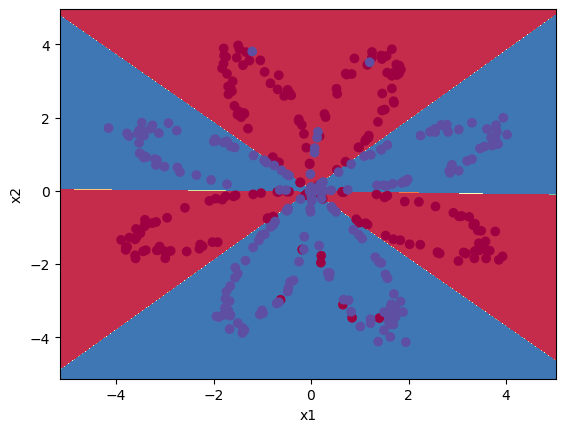

In [82]:
plot_division(perceptron)

In [ ]:
# 40 нейронов

In [85]:
perceptron = Perceptron(X, Y, 40)
perceptron.learn(10000, 0.1, 0.1)

MSE loss: 0.49928892390679375, MSE_Reg loss: 0.5102046795537709, CE loss: 3.46265917569693
MSE loss: 0.05275512108303253, MSE_Reg loss: 0.13398151751968432, CE loss: 0.34371594358969015
MSE loss: 0.05224344651277095, MSE_Reg loss: 0.2132823182043982, CE loss: 0.4286952500804146
MSE loss: 0.03748107928631231, MSE_Reg loss: 0.2786958101932285, CE loss: 0.3837153915431957
MSE loss: 0.03572055629388484, MSE_Reg loss: 0.3249344992607695, CE loss: 0.40186346099806664
MSE loss: 0.03415575657705438, MSE_Reg loss: 0.3588092436353219, CE loss: 0.408519457822233
MSE loss: 0.03185516461614669, MSE_Reg loss: 0.3862606710109842, CE loss: 0.4098409240371011
MSE loss: 0.030683848390248, MSE_Reg loss: 0.40673504793467646, CE loss: 0.40641219544291957
MSE loss: 0.029722499217940807, MSE_Reg loss: 0.42489819104605725, CE loss: 0.40164012692384005
MSE loss: 0.031830390050317826, MSE_Reg loss: 0.4430172194064087, CE loss: 0.4063845442217708


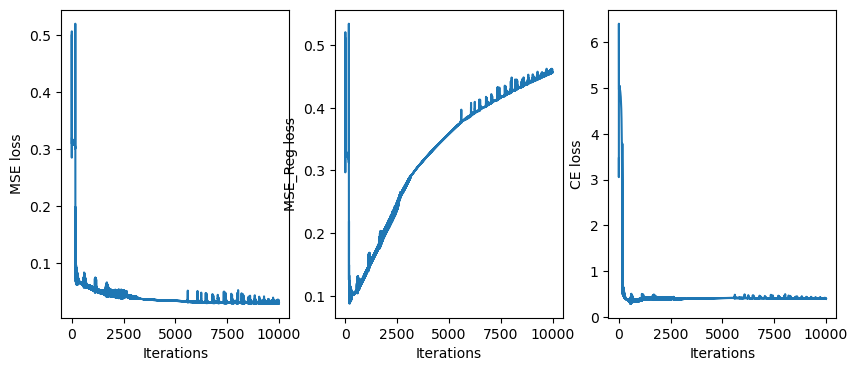

In [87]:
perceptron.plot()

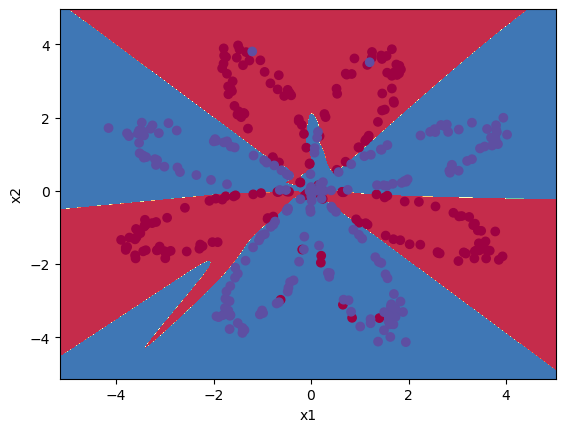

In [88]:
plot_division(perceptron)

In [ ]:
# lmdb = 0.1 вполне подходит, заметим что у нас появился "носик", который захватает синие точки, без регуляризации такого не было
# можно также заметить, что mse_reg возрастает до ~ 0.45 и дальше не растет, асимптота, 
# в начале может быть подскочить, но к концу упирается в ограничение, результат нашего штрафа и lmdb

In [92]:
perceptron = Perceptron(X, Y, 40)
perceptron.learn(10000, 0.1, 0.1)

MSE loss: 0.2836737453806115, MSE_Reg loss: 0.30006587702121534, CE loss: 0.8544857691307239
MSE loss: 0.06107311339398971, MSE_Reg loss: 0.13221218647522748, CE loss: 0.3892898853767195
MSE loss: 0.040414383898614015, MSE_Reg loss: 0.20200688489627389, CE loss: 0.38203713363564545
MSE loss: 0.039307435223116166, MSE_Reg loss: 0.2891833043026929, CE loss: 0.42548935165718194
MSE loss: 0.03724444774495389, MSE_Reg loss: 0.3376558069964186, CE loss: 0.4513434395897719
MSE loss: 0.03447903834738414, MSE_Reg loss: 0.36164699485308455, CE loss: 0.44578144457105723
MSE loss: 0.03228223235461965, MSE_Reg loss: 0.38116059348320763, CE loss: 0.4380971107685636
MSE loss: 0.0327139966118806, MSE_Reg loss: 0.3963867014222487, CE loss: 0.4405841866708547
MSE loss: 0.03205598030642816, MSE_Reg loss: 0.40876743014043104, CE loss: 0.4394155069962708
MSE loss: 0.03316972015874711, MSE_Reg loss: 0.42182617944407746, CE loss: 0.44614427478344404


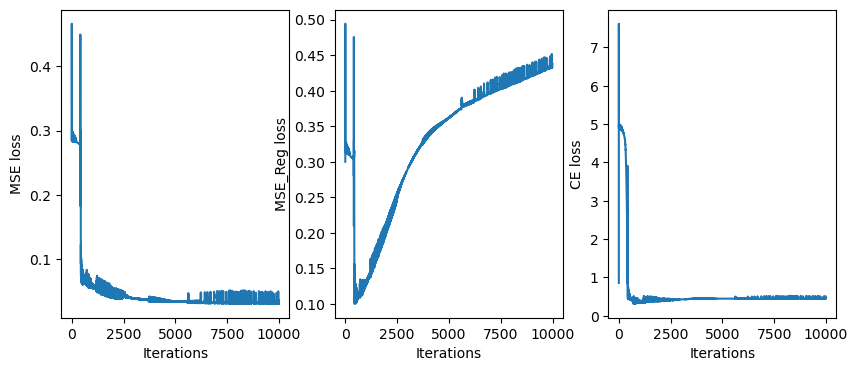

In [94]:
perceptron.plot()

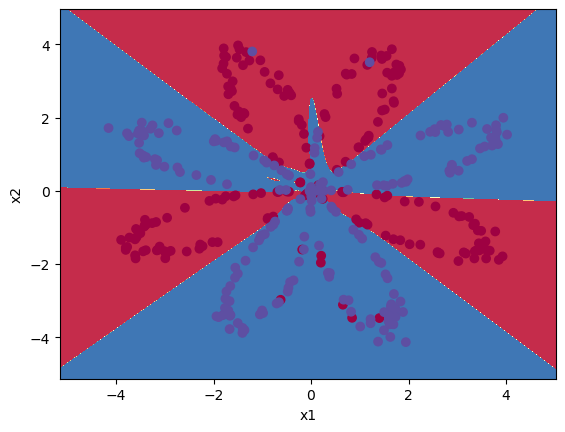

In [96]:
plot_division(perceptron)

In [ ]:
# просто убедился, что не случайность, в доказательство 2 подряд картинки

In [98]:
perceptron = Perceptron(X, Y, 100)
perceptron.learn(10000, 0.1, 0.1)

MSE loss: 0.343842160353948, MSE_Reg loss: 0.3853986414248196, CE loss: 1.2968442412763272
MSE loss: 0.27762365968465247, MSE_Reg loss: 0.37305290270588837, CE loss: 4.810238217026082
MSE loss: 0.05343735784208139, MSE_Reg loss: 0.2251668446751936, CE loss: 0.6483971423306631
MSE loss: 0.046145338273968085, MSE_Reg loss: 0.2931595403364301, CE loss: 0.6125809549627174
MSE loss: 0.04428276426577577, MSE_Reg loss: 0.3377041135168253, CE loss: 0.6061571784557427
MSE loss: 0.042544809552941126, MSE_Reg loss: 0.3612436860261105, CE loss: 0.6066704056047083
MSE loss: 0.0465031563532997, MSE_Reg loss: 0.3817765580890827, CE loss: 0.6106523443596418
MSE loss: 0.04109759392651466, MSE_Reg loss: 0.3882262506411176, CE loss: 0.5914456284487731
MSE loss: 0.041465586862801045, MSE_Reg loss: 0.3975317144954801, CE loss: 0.5889787514048761
MSE loss: 0.04228082217073885, MSE_Reg loss: 0.4051182108131928, CE loss: 0.5870488117601549


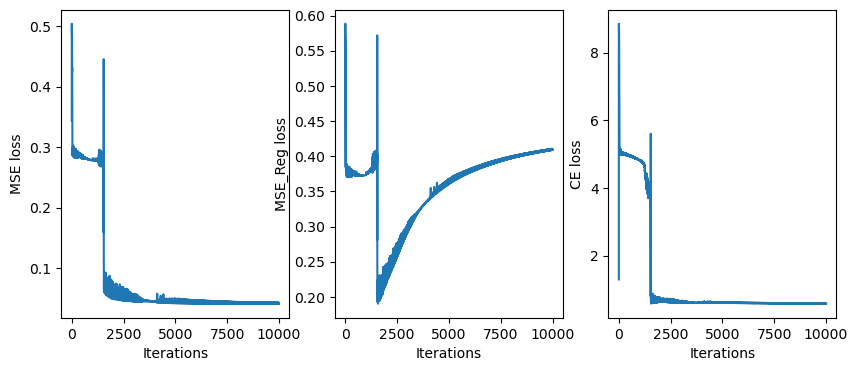

In [99]:
perceptron.plot()

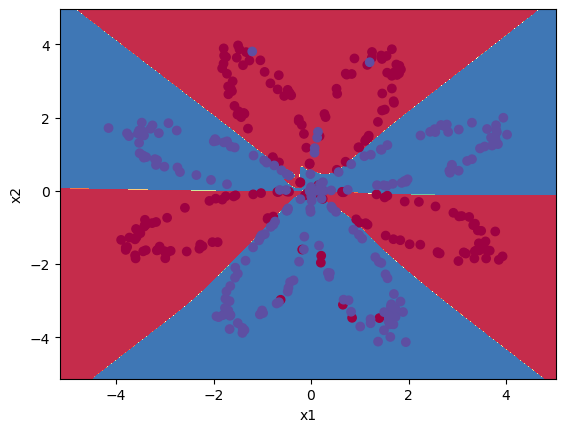

In [100]:
plot_division(perceptron)

In [ ]:
# здесь пропадает "носик", думаю из-за маленькой lmdb

In [ ]:
# попробовал 0.2, 1, дошел до 5 и получил снова хороший результат
# из интересного у нас много скачков на функциях потерь
# вв конце mse_reg упирается уже в 2.6, так как lmdb уже 5, а не 0.1

In [116]:
perceptron = Perceptron(X, Y, 100)
perceptron.learn(10000, 0.1, 5)

MSE loss: 0.3076708747790061, MSE_Reg loss: 2.070511299427921, CE loss: 2.754858539826794
MSE loss: 0.07726300729422221, MSE_Reg loss: 1.9927689189459632, CE loss: 0.46871735436437606
MSE loss: 0.0708201226571721, MSE_Reg loss: 1.7524227185603312, CE loss: 0.3970478984903237
MSE loss: 0.06393912648474774, MSE_Reg loss: 2.2885234925070908, CE loss: 0.6206027192009621
MSE loss: 0.06714625906460443, MSE_Reg loss: 1.7879216158324684, CE loss: 0.2418121004850899
MSE loss: 0.06073975263601614, MSE_Reg loss: 1.8340969237974427, CE loss: 0.19839091601053485
MSE loss: 0.05398881566866777, MSE_Reg loss: 2.3455269306092976, CE loss: 0.1851373674831828
MSE loss: 0.0492795948525648, MSE_Reg loss: 2.5198122987710243, CE loss: 0.1723458778864599
MSE loss: 0.052818115571760804, MSE_Reg loss: 2.541889653384768, CE loss: 0.17974550215243912
MSE loss: 0.054836443065206346, MSE_Reg loss: 2.540744178235985, CE loss: 0.18697081027133128


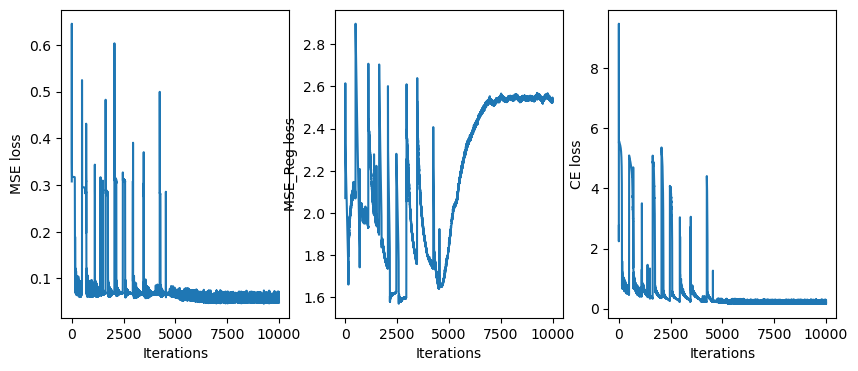

In [117]:
perceptron.plot()

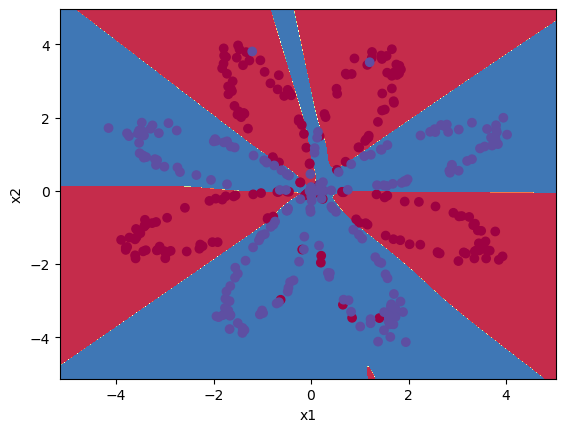

In [118]:
plot_division(perceptron)

In [ ]:
# привел, чтобы показать, что при lmdb = 1 не хватает, так как на графике mse_reg функция возрастает и не достигает асимпототы
# значит надо повышать штраф

In [122]:
perceptron = Perceptron(X, Y, 100)
perceptron.learn(10000, 0.1, 1)

MSE loss: 0.4466225600602083, MSE_Reg loss: 0.7613242749633953, CE loss: 2.29279995974074
MSE loss: 0.06509219275870742, MSE_Reg loss: 0.8829857215965822, CE loss: 0.620384111929708
MSE loss: 0.053259480951021926, MSE_Reg loss: 1.1718589492590452, CE loss: 0.6359030038911229
MSE loss: 0.057086568071479854, MSE_Reg loss: 1.354134740199373, CE loss: 0.6220928528129304
MSE loss: 0.0554382820639254, MSE_Reg loss: 1.4620205524432548, CE loss: 0.6472452064681634
MSE loss: 0.054434259221084254, MSE_Reg loss: 1.5238267615469396, CE loss: 0.6552813556281579
MSE loss: 0.053566173632231796, MSE_Reg loss: 1.5530255406244011, CE loss: 0.6471970730247998
MSE loss: 0.05301243909783377, MSE_Reg loss: 1.5584786630516136, CE loss: 0.6409023999988303
MSE loss: 0.05263130764905768, MSE_Reg loss: 1.5574174719980194, CE loss: 0.6318406106290977
MSE loss: 0.05091376958242608, MSE_Reg loss: 1.5656914625615448, CE loss: 0.609512243472047


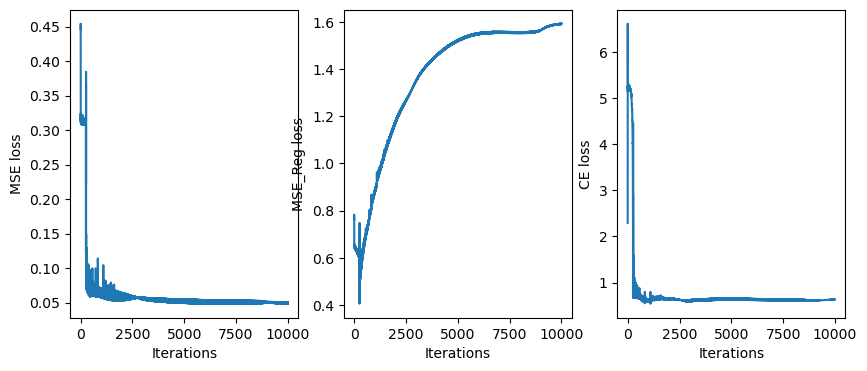

In [123]:
perceptron.plot()

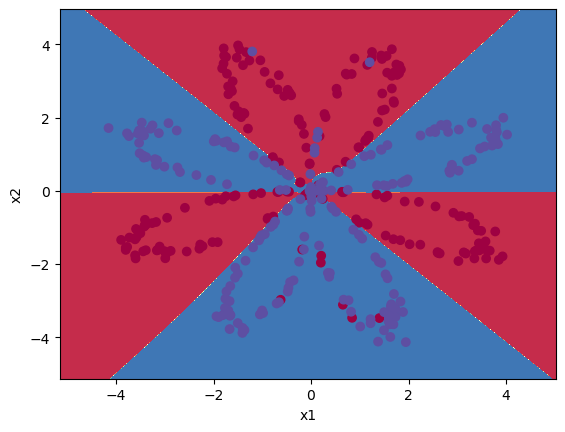

In [124]:
plot_division(perceptron)

In [ ]:
# Немножко о L2 своими словами и выводы
# L2 регуляризация - это метод борьбы с переобучением, который приносит штраф за сложность,
# а именно за большие веса. В mse появляется слагаемое + lmdb / (2*m) * sum(W), 
# а при изменении веса + (lmdb / m * W2). 
# Главные достоинства: убирает сложные извилистые границы, меньше чувствительности к шуму, находит общие закономерности.
# По моему мнению, переобучение на цветочке плохо показывается. Есть примеры получше, для цветочка картинка для 4 нейронов и с 40 с переобучением одинакова.
# Однако куда лучше показывает общие закономерности с регуляризацией. Это появления "носика", который выделяет нужные элементы класса.

In [134]:
Y

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [162]:
m = X.shape[1]
indices = np.random.permutation(m)
test_size = int(0.5 * m)

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train = X[:, train_indices] 
X_test = X[:, test_indices]    
y_train = Y[:, train_indices]    
y_test = Y[:, test_indices]    

In [ ]:
# скопировали все, чтобы поменять predict

In [ ]:
from matplotlib import pyplot as plt

class Perceptron:
    def __init__(self, X, Y, hidden_size):
        
        # Пусть n - количество признаков, m - количество объектов, k - размерность результирующего вектора
        # Тогда X = X(n * m), Y = Y(k, m)
        assert X.shape[1] == Y.shape[1]
        self.X = X
        self.Y = Y
        self.m = X.shape[1]
        
        # Инициализируем матрицы весов рандомными числами (W1 - для скрытого слоя, W2 - для выходного, в нем всего 1 нейрон)
        self.W1 = np.random.randn(hidden_size, X.shape[0])
        self.W2 = np.random.randn(Y.shape[0], hidden_size)
        
        # Заполняем свободные векторы нулями
        self.b1 = np.zeros((hidden_size, 1))
        self.b2 = np.zeros((Y.shape[0], 1))
        
        # Здесь будем накапливать значения функции потерь на каждой итерации
        self.ce_loss = []
        self.mse_loss = []
        self.mse_loss_reg = [] # добавили массив для mse с регуляризацией
        
    def learn(self, iter_num, learning_rate, lmdb):
        
        # Итерируемся необходимое количество раз
        for i in range(iter_num):
            
            # Расчет взыешенных сумм каждого из нейронов, применение функций активации
            # Для того, чтобы заменить функции активации, необходимо заменить функцию при вычислении А1/А2
            Z1 = np.dot(self.W1, self.X) + self.b1                                     # (hidden_size, X.shape[1])
            A1 = tanh(Z1)
            Z2 = np.dot(self.W2, A1) + self.b2                                         # (Y.shape[0], X.shape[1] = Y.shape[1])
            A2 = sigmoid(Z2)

            # Среднеквадратичная (MSE) функция потерь
            mse_loss = np.sum((A2 - self.Y) ** 2) / self.m
            mse_loss_reg = np.sum((A2 - self.Y) ** 2) / self.m + lmdb / (2*self.m) * np.sum(self.W1**2) + lmdb / (2*self.m) * np.sum(self.W2**2) 
            # + lmdb / (2*self.m) * np.sum(self.W1**2) + lmdb / (2*self.m) * np.sum(self.W2**2)
            # добавил штраф за сложность с параметром lmdb, регуляризацию L2, за веса W1 и W2
            # в описании задания квадрата не было, но по лекциям из ML это LASSO регуляризация (правда еще модуль добавить надо), поэтому скорее всего опечатка и нужен квадрат, 
            # тем более в подсказке говорится о квадратах
            
            # Cross entropy функция потерь
            eps = 1e-8
            logprobs = self.Y * np.log(A2 + eps) + (1 - self.Y) * np.log(1 - A2 + eps)
            ce_loss = (-1 / self.m) * np.sum(logprobs)
            
            # Запоминание значения функции потерь и печать на каждой 1000-й итерации
            self.mse_loss.append(mse_loss)
            self.mse_loss_reg.append(mse_loss_reg)
            self.ce_loss.append(ce_loss)
            if i % 1000 == 0: print(f"MSE loss: {mse_loss}, MSE_Reg loss: {mse_loss_reg}, CE loss: {ce_loss}")

            # Алгоритм обратного распространения ошибки
            # Производные высчитываются по правилу производной для сложной функции
            # Оптимизируется среднеквадратичная функция потерь
            # Для оптимизации cross entropy необходимо заменить производную функции потерь по A2 - self.Y
            # Для этого необходимо найти dError/dW
            # При замене функций активации необходимо также заменить соответствующую ей производную
            dA2 = (A2 - self.Y) * dsigmoid(A2)        # dLoss/dA * dSig/dZ2            # (Y.shape[0], Y.shape[1] = X.shape[1])
            # dW2 = np.dot(dA2, A1.T)                   # dZ2/dW2                        # (Y.shape[0], hidden_size)
            dW2 = np.dot(dA2, A1.T) + (lmdb / self.m * self.W2)  # + (lmdb / m * W2), взяли производную по W2 поэтому 2-ки сократились, регуляризация L2, штраф за сложность 
            db2 = np.sum(dA2, axis=1, keepdims=True)                                   # (Y.shape[0], 1)
            dA1 = np.dot(self.W2.T, dA2) * dtanh(A1)  # dA2 * dZ2/dA1 * dTanh/dZ       # (hidden_size, Y.shape[1] = X.shape[1])
            # dW1 = np.dot(dA1, self.X.T)               # dZ1/dW                         # (hidden_size, X.shape[0])
            dW1 = np.dot(dA1, self.X.T) + (lmdb / self.m * self.W1) # аналогично dW2 
            db1 = np.sum(dA1, axis=1, keepdims=True)                                   # (hidden_size, 1)
            
            # Обновление весов методом градиентного спуска
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1
            
    def predict(self, X):
        # Используем найденные матрицы весов
        A1 = tanh(np.dot(self.W1, X) + self.b1)
        A2 = sigmoid(np.dot(self.W2, A1) + self.b2)
        return A2[0]
    
    def plot(self):
        plt.figure(figsize=(10,4))
        plt.subplot(1, 3, 1)
        plt.ylabel('MSE loss')
        plt.xlabel('Iterations')
        plt.plot(self.mse_loss)
        plt.subplot(1, 3, 2)
        plt.ylabel('MSE_Reg loss')
        plt.xlabel('Iterations')
        plt.plot(self.mse_loss_reg)
        plt.subplot(1, 3, 3)
        plt.ylabel('CE loss')
        plt.xlabel('Iterations')
        plt.plot(self.ce_loss)

In [164]:
perceptron1 = Perceptron(X_train, y_train, 40)
perceptron1.learn(10000, 0.1, 0)

MSE loss: 0.32259348856644016, MSE_Reg loss: 0.32259348856644016, CE loss: 1.6119994750864224
MSE loss: 0.05374522310257215, MSE_Reg loss: 0.05374522310257215, CE loss: 0.728417516797202
MSE loss: 0.0504165397975168, MSE_Reg loss: 0.0504165397975168, CE loss: 0.7458538666823447
MSE loss: 0.04770440136245717, MSE_Reg loss: 0.04770440136245717, CE loss: 0.7351119157667474
MSE loss: 0.04622092678416848, MSE_Reg loss: 0.04622092678416848, CE loss: 0.7286975838938526
MSE loss: 0.04536441620320389, MSE_Reg loss: 0.04536441620320389, CE loss: 0.7243942708516511
MSE loss: 0.0446895813940006, MSE_Reg loss: 0.0446895813940006, CE loss: 0.7213879280995706
MSE loss: 0.04410333928313715, MSE_Reg loss: 0.04410333928313715, CE loss: 0.7198672026789373
MSE loss: 0.0436497868681247, MSE_Reg loss: 0.0436497868681247, CE loss: 0.719648435472777
MSE loss: 0.04334819811791074, MSE_Reg loss: 0.04334819811791074, CE loss: 0.720253389816154


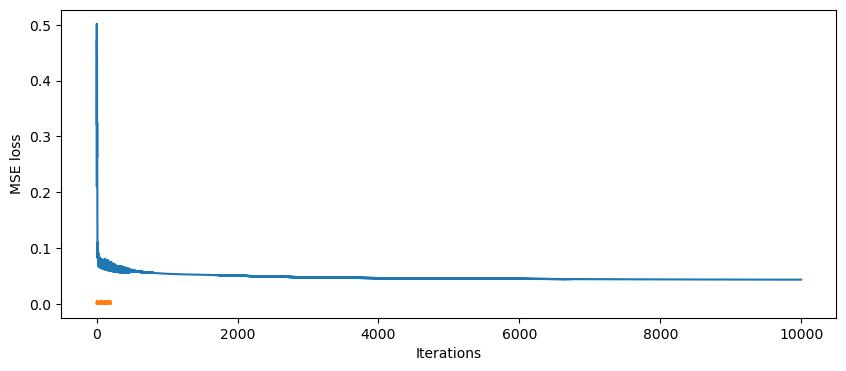

In [165]:
a = perceptron1.predict(X_test)
m = X_train.shape[1]
mse_test=[]
for i in range(len(a)):
    mse_loss = np.sum((a[i] - y_test[0][i]) ** 2) / m
    mse_test.append(mse_loss)

plt.figure(figsize=(10,4))
plt.subplot(1, 1, 1)
plt.ylabel('MSE loss')
plt.xlabel('Iterations')
plt.plot(perceptron1.mse_loss)
plt.plot(mse_test)
    

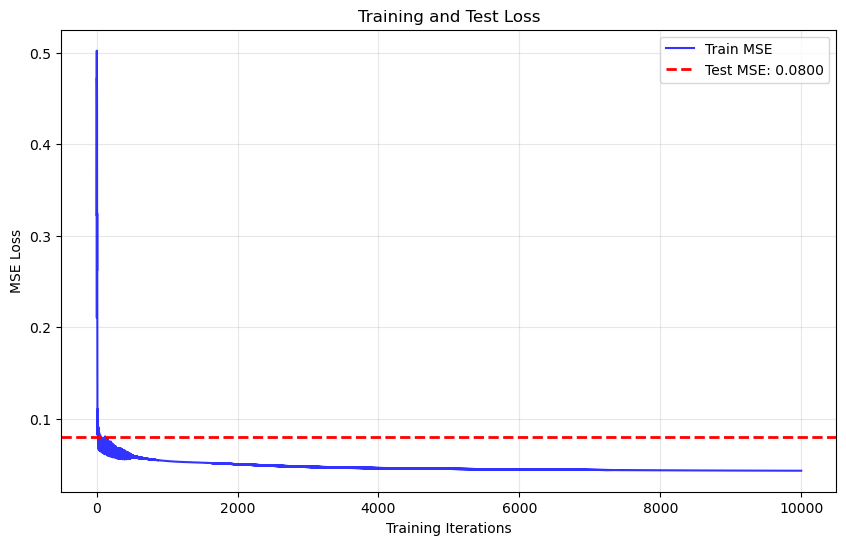

Final Train MSE: 0.0431
Test MSE: 0.0800


In [166]:
a = perceptron1.predict(X_test)
mse_test = np.sum((a - y_test) ** 2) / y_test.shape[1]

plt.figure(figsize=(10, 6))

# Обучающая выборка
plt.plot(perceptron1.mse_loss, 'b-', label='Train MSE', linewidth=1.5, alpha=0.8)

# Тестовая выборка - горизонтальная линия на уровне финального значения
plt.axhline(y=mse_test, color='red', linestyle='--', linewidth=2, label=f'Test MSE: {mse_test:.4f}')

plt.ylabel('MSE Loss')
plt.xlabel('Training Iterations')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Train MSE: {perceptron1.mse_loss[-1]:.4f}")
print(f"Test MSE: {mse_test:.4f}")

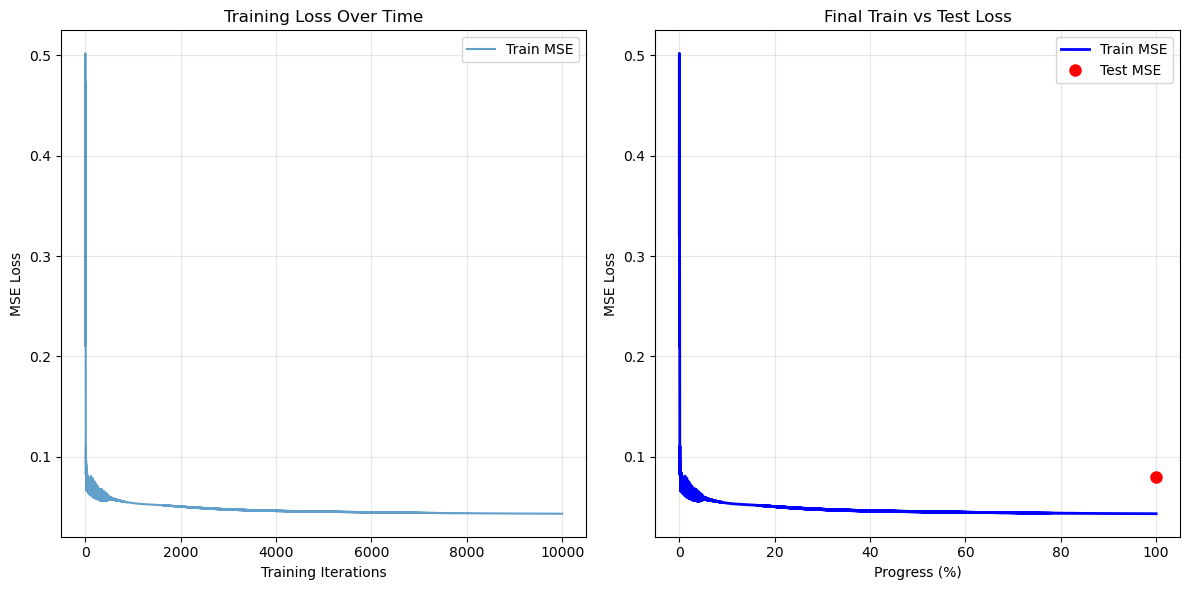

Final Train MSE: 0.0431
Test MSE: 0.0800


In [172]:
a = perceptron1.predict(X_test)
mse_test = np.sum((a - y_test) ** 2) / y_test.shape[1]

plt.figure(figsize=(12, 6))

# График обучения
plt.subplot(1, 2, 1)
plt.plot(perceptron1.mse_loss, label='Train MSE', alpha=0.7)
plt.ylabel('MSE Loss')
plt.xlabel('Training Iterations')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# График сравнения train/test
plt.subplot(1, 2, 2)
iterations = len(perceptron1.mse_loss)
x_train = np.linspace(0, 100, iterations)  # Нормализуем до 100%
x_test = [100]  # Тестовая точка в конце

plt.plot(x_train, perceptron1.mse_loss, 'b-', label='Train MSE', linewidth=2)
plt.plot(x_test, mse_test, 'ro', markersize=8, label='Test MSE')
plt.ylabel('MSE Loss')
plt.xlabel('Progress (%)')
plt.title('Final Train vs Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Train MSE: {perceptron1.mse_loss[-1]:.4f}")
print(f"Test MSE: {mse_test:.4f}")

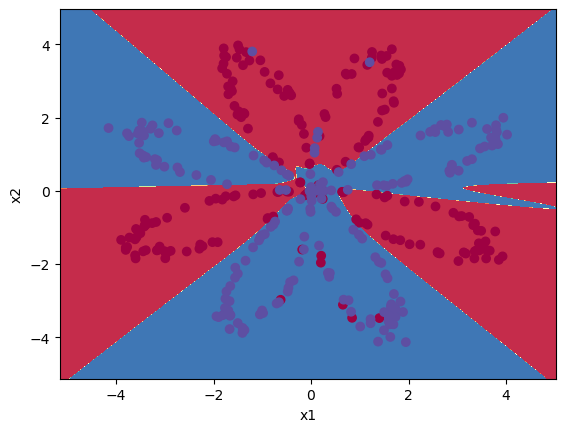

In [167]:
plot_division(perceptron1)

In [208]:
perceptron1 = Perceptron(X_train, y_train, 40)
perceptron1.learn(10000, 0.1, 1)

MSE loss: 0.41301269662908313, MSE_Reg loss: 0.7067620675527707, CE loss: 3.2735345073987903
MSE loss: 0.058981475817025245, MSE_Reg loss: 0.6256583963992994, CE loss: 0.6331173994035525
MSE loss: 0.055637401563492866, MSE_Reg loss: 0.6889463055236742, CE loss: 0.6927820946448321
MSE loss: 0.05467824828364187, MSE_Reg loss: 0.7038509362833265, CE loss: 0.6795713058851492
MSE loss: 0.05419632959033824, MSE_Reg loss: 0.7097238776512593, CE loss: 0.6679054945468765
MSE loss: 0.053906788700568115, MSE_Reg loss: 0.7146914213330131, CE loss: 0.6621057437134256
MSE loss: 0.05372525218393814, MSE_Reg loss: 0.7175999610093385, CE loss: 0.6536480107771513
MSE loss: 0.05362112455759795, MSE_Reg loss: 0.7192542106641989, CE loss: 0.648049170523024
MSE loss: 0.05355984993590567, MSE_Reg loss: 0.7195042997697073, CE loss: 0.6439349778339493
MSE loss: 0.0535183554004943, MSE_Reg loss: 0.7189010433569595, CE loss: 0.6388416764216467


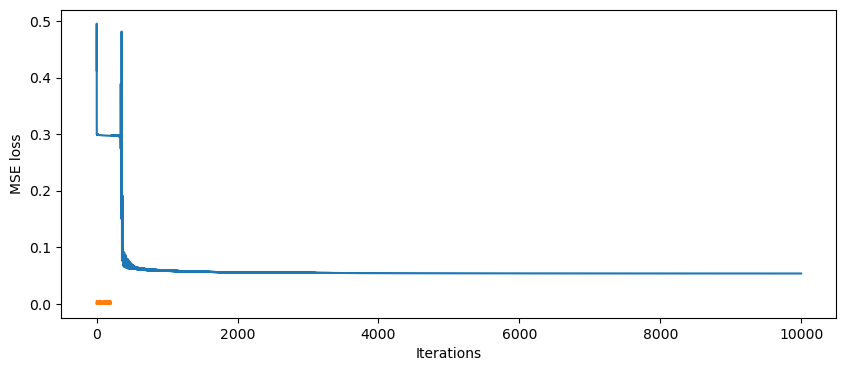

In [209]:
a = perceptron1.predict(X_test)
m = X_train.shape[1]
mse_test=[]
for i in range(len(a)):
    mse_loss = np.sum((a[i] - y_test[0][i]) ** 2) / m
    mse_test.append(mse_loss)

plt.figure(figsize=(10,4))
plt.subplot(1, 1, 1)
plt.ylabel('MSE loss')
plt.xlabel('Iterations')
plt.plot(perceptron1.mse_loss)
plt.plot(mse_test)
    

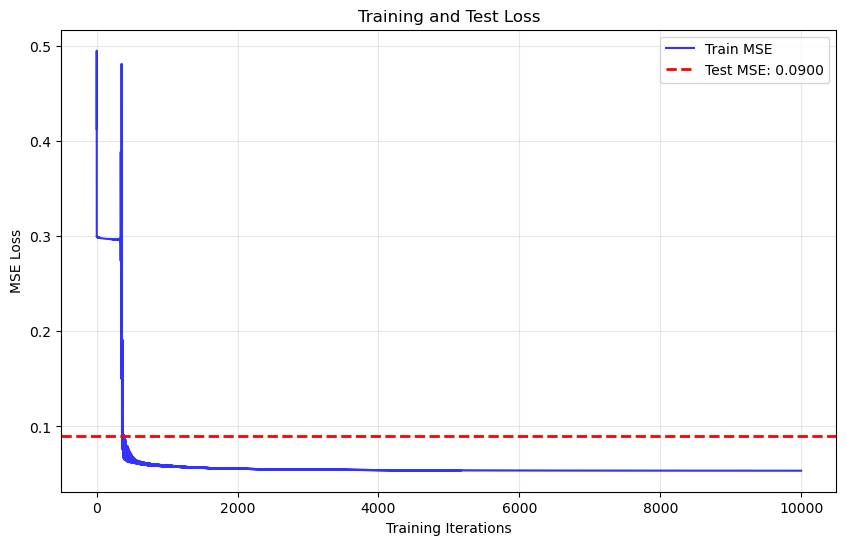

Final Train MSE: 0.0534
Test MSE: 0.0900


In [210]:
a = perceptron1.predict(X_test)
mse_test = np.sum((a - y_test) ** 2) / y_test.shape[1]

plt.figure(figsize=(10, 6))

# Обучающая выборка
plt.plot(perceptron1.mse_loss, 'b-', label='Train MSE', linewidth=1.5, alpha=0.8)

# Тестовая выборка - горизонтальная линия на уровне финального значения
plt.axhline(y=mse_test, color='red', linestyle='--', linewidth=2, label=f'Test MSE: {mse_test:.4f}')

plt.ylabel('MSE Loss')
plt.xlabel('Training Iterations')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Train MSE: {perceptron1.mse_loss[-1]:.4f}")
print(f"Test MSE: {mse_test:.4f}")

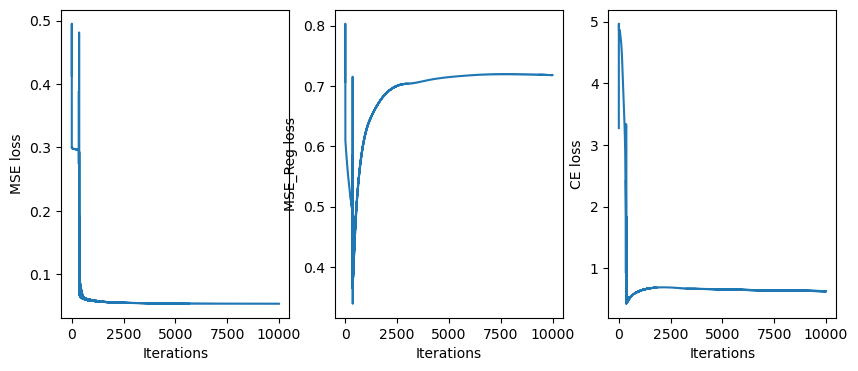

In [213]:
perceptron1.plot()